# Milestone 4 — Persistent homology and simpler controls
**Joel Cerraga · Market-Neutral Trading Algorithm**

This notebook computes causal H0/H1 descriptors of the same 24-stock basket and compares them with mean correlation and volatility. The primary window is 126 sessions; 63 and 252 sessions are retained as sensitivities. **There is no topology trading overlay or return-prediction target in this milestone.**

As Edelsbrunner et al. (2002) explain in *Topological Persistence and Simplification*, persistence tracks the birth and death of features through a filtration. Gidea and Katz (2018), in *Topological data analysis of financial time series: Landscapes of crashes*, apply related ideas to financial time series. Their point clouds differ from the asset-correlation geometry used here; this is not a replication or a crash-prediction claim.

The baseline and graph outcomes were already known before this feature protocol was frozen. The final 2020–2025 holdout remains unavailable. Final PDF compilation is deferred; the working manuscript and Harvard references are maintained as editable sources.

> Current project status after Milestone 5: the 2020–2025 reserved test has now been evaluated. This notebook retains its earlier milestone calculations and information state; see `05-final-evaluation.ipynb` for the final findings.


In [1]:
from pathlib import Path
import json, sys, inspect
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if not (ROOT / "market_neutral").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from market_neutral.historical import assemble_dataset
from market_neutral.topology import (load_topology_protocol, run_topology, persistence,
                                    summarise, correlation_distance, landscape, FEATURES)
from market_neutral.topology_plots import create_topology_figures
output = ROOT / "outputs/topology"
print("Working folder:", ROOT.name)

Working folder: Market-Neutral-Trading-Algorithm


## 1. Verify the protocol and existing inputs
The lock precedes topology extraction. All three windows are available from 4 January 2010: the first date includes exactly 252 daily returns for the longest window. No dates are silently dropped and no extra history is acquired.

As Mantegna (1999) explains in *Hierarchical structure in financial markets*, correlations can be converted to distances. The complete matrix is used here, including negative correlations. The sparse positive-neighbour trading graph is a different object.

In [2]:
protocol = load_topology_protocol(ROOT)
dataset, audit = assemble_dataset(ROOT)
assert dataset.metadata["input_sha256"] == protocol["input_sha256"]
assert dataset.prices.index.max() < pd.Timestamp("2020-01-01")
display(pd.DataFrame({"Setting": ["Primary window", "All windows", "Feature definitions", "Holdout"],
                      "Value": [str(protocol["primary_window"]), str(protocol["windows"]),
                                ", ".join(protocol["features"]), protocol["holdout"]]}))

,Setting,Value
0,Primary window,126
1,All windows,"[63, 126, 252]"
2,Feature definitions,"h0_mean, h0_max, h1_total, h1_max"
3,Holdout,"Do not download, calculate topology for or eva..."


## 2. Understand the geometry and check known shapes

$$d_{ij,t}=\sqrt{2(1-\rho_{ij,t})}=\|u_{i,t}-u_{j,t}\|_2 \tag{21}$$

Here each u is the centred unit-length trailing return vector. As Bauer (2021) describes in *Ripser: efficient computation of Vietoris–Rips persistence barcodes*, the filtration adds simplices as their edge distances become admissible. Tralie et al. (2018), in *Ripser.py: A lean persistent homology library for Python*, describe the Python interface.

A square has an H1 interval from edge length 1 to diagonal length √2. A filled triangle has no positive-lifetime H1 interval. One essential H0 bar is excluded explicitly; it is not replaced by an arbitrary large number.

In [3]:
from scipy.spatial.distance import pdist, squareform
square = np.array([[0.,0.], [1.,0.], [1.,1.], [0.,1.]])
known = persistence(squareform(pdist(square)))
np.testing.assert_allclose(known["h1"], [[1., np.sqrt(2)]], atol=2e-7)
display(pd.DataFrame(known["h1"], columns=["birth", "death"]))
print("Essential H0 intervals:", known["essential_h0"])
print(inspect.getsource(correlation_distance))

Essential H0 intervals: 1
def correlation_distance(history):
    """Asset distances: Euclidean chords between centred unit return vectors."""
    r = np.asarray(history, dtype=float)
    if r.ndim != 2 or min(r.shape) < 2 or not np.isfinite(r).all():
        raise ValueError("Need finite time-by-asset observations")
    centered = r - r.mean(axis=0)
    norms = np.linalg.norm(centered, axis=0)
    if (norms <= 1e-12).any():
        raise ValueError("Constant asset: correlation geometry is undefined")
    unit = centered / norms
    corr = np.clip(unit.T @ unit, -1., 1.)
    corr = (corr + corr.T) / 2
    np.fill_diagonal(corr, 1.)
    distance = np.sqrt(2 * (1 - corr))
    np.fill_diagonal(distance, 0.)
    return corr, distance



,birth,death
0,1.0,1.414214


## 3. Execute the complete feature protocol
Each feature dated t uses only returns through t. A later trading application would still need the existing execution delay. The shared implementation writes every feature/window combination, control fit, residual and monthly diagram.

The first execution here reproduces the stored output hashes. A changed input snapshot is rejected by the protocol; the hash guard must not be edited to force a pass.

In [4]:
expected = json.loads((output / "run-manifest.json").read_text())["files"] if (output / "run-manifest.json").exists() else None
features, manifest = run_topology(ROOT, dataset)
if expected is not None:
    assert manifest["files"] == expected
create_topology_figures(ROOT)
print(f"{manifest['feature_rows']:,} rows; {manifest['dates_per_window']:,} common dates; {manifest['diagram_bound_checks']} diagram-bound checks")
print(f"Feature extraction: {manifest['feature_computation_seconds']:.2f} seconds in this environment")
assert len(features) == 7548
assert features.essential_h0.eq(1).all() and features.finite_h0.eq(23).all()
display(features.loc[features.window == 126, [*FEATURES, "mean_correlation"]].head())

7,548 rows; 2,516 common dates; 480 diagram-bound checks
Feature extraction: 3.09 seconds in this environment


,h0_mean,h0_max,h1_total,h1_max,mean_correlation
date,,,,,
2010-01-04,0.915373,1.196690,0.061773,0.036728,0.334850
2010-01-05,0.920784,1.192209,0.099464,0.058680,0.329069
2010-01-06,0.922607,1.186008,0.118604,0.062643,0.330686
2010-01-07,0.921224,1.183373,0.104402,0.056439,0.332692
2010-01-08,0.919261,1.185358,0.101921,0.058064,0.331373


## 4. Inspect the descriptors over time
H0 mean/final merger distances describe how components join. H1 total/maximum persistence summarise cycles before they are filled. An empty H1 diagram has zero total and maximum. Every positive interval is retained, without a fitted threshold.

These are descriptors in distance units. Peaks are not forecast returns or probabilities of a crash.

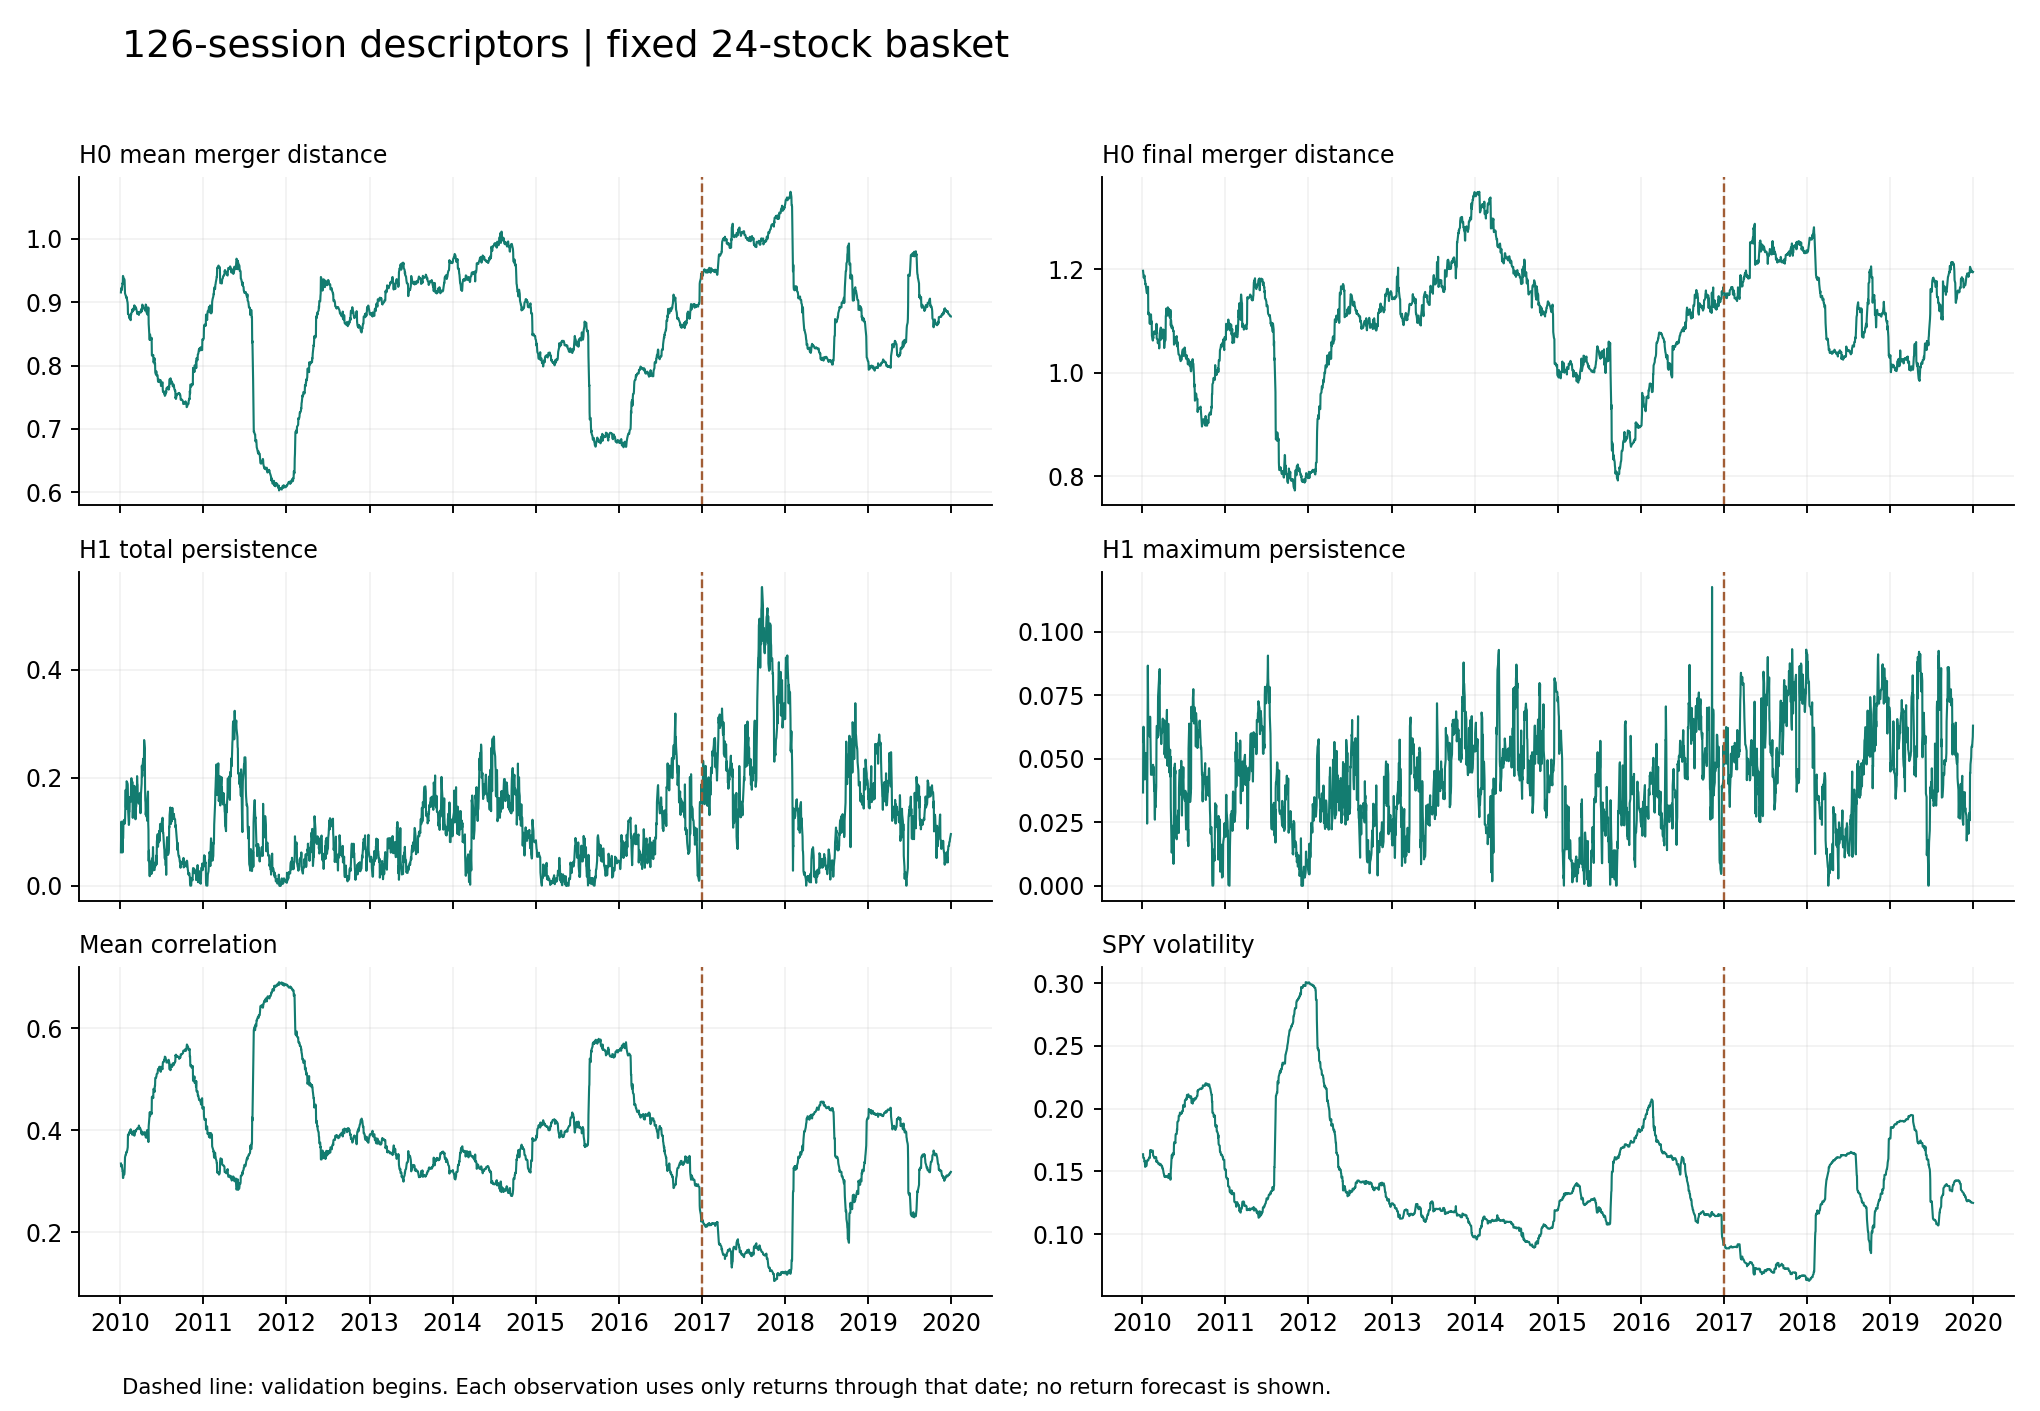

# Milestone 4: topology descriptors and simpler controls

The frozen protocol evaluates four features at 63, 126 and 252 sessions on 2,516 identical decision dates. The primary window remains 126 sessions. No trading overlay was introduced.

## Primary-window correlations with mean correlation

| Feature | Development Spearman | Validation Spearman |
| --- | ---: | ---: |
| H0 mean merger distance | -0.935 | -0.968 |
| H0 final merger distance | -0.879 | -0.890 |
| H1 total persistence | -0.593 | -0.667 |
| H1 maximum persistence | -0.463 | -0.421 |

## Approximation using the three simpler controls

Ordinary least squares uses an intercept, mean correlation, mean stock volatility and SPY volatility. All centring, scaling and coefficients use development only. R² scores the topology feature, not a trading return.

| Feature | Development R² | Validation R² |
| --- | ---: | ---: |
| H0 mean merger distance | 0.959 | 0.563 |
| H0 final merger distance | 0.810 | -0.195 |
| H1 total persistence | 0.345 | 0.343 |
| H1 maximum persistence | 0.223 | 0.303 |

A negative validation R² means that the transferred development model has larger squared error than a constant equal to the validation feature mean. That mean is used only as a scoring benchmark. Unexplained variation is not evidence of predictive or economic value.

All window comparisons, fit coefficients, row-level residuals and numerical stability checks are retained in the companion CSV/JSON files. Overlapping windows make these observations dependent; no independent-observation significance claims are made.


In [5]:
display(Image(filename=str(output / "09-topology-features.png")))
display(Markdown((output / "milestone-4-results.md").read_text()))

## 5. Compare with ordinary correlation and volatility
The descriptive control model uses an intercept and three same-window controls. As Golub and Van Loan (2013) explain in *Matrix Computations*, least squares supplies a standard approximation framework. Every mean, scale and coefficient below is fitted using development data only.

$$R^2_{\mathcal P}=1-\frac{\sum_{t\in\mathcal P}(f_t-\widehat f_t)^2}{\sum_{t\in\mathcal P}(f_t-\bar f_{\mathcal P})^2}\tag{25}$$

The phase mean is only a scoring benchmark. A negative validation R² is retained. The response variable is a topological descriptor, not a portfolio return. Low explanatory R² cannot establish new predictive information.

phase,development,validation
feature,,
h0_max,0.810240,-0.194968
h0_mean,0.958942,0.562830
h1_max,0.223490,0.302945
h1_total,0.344806,0.343373


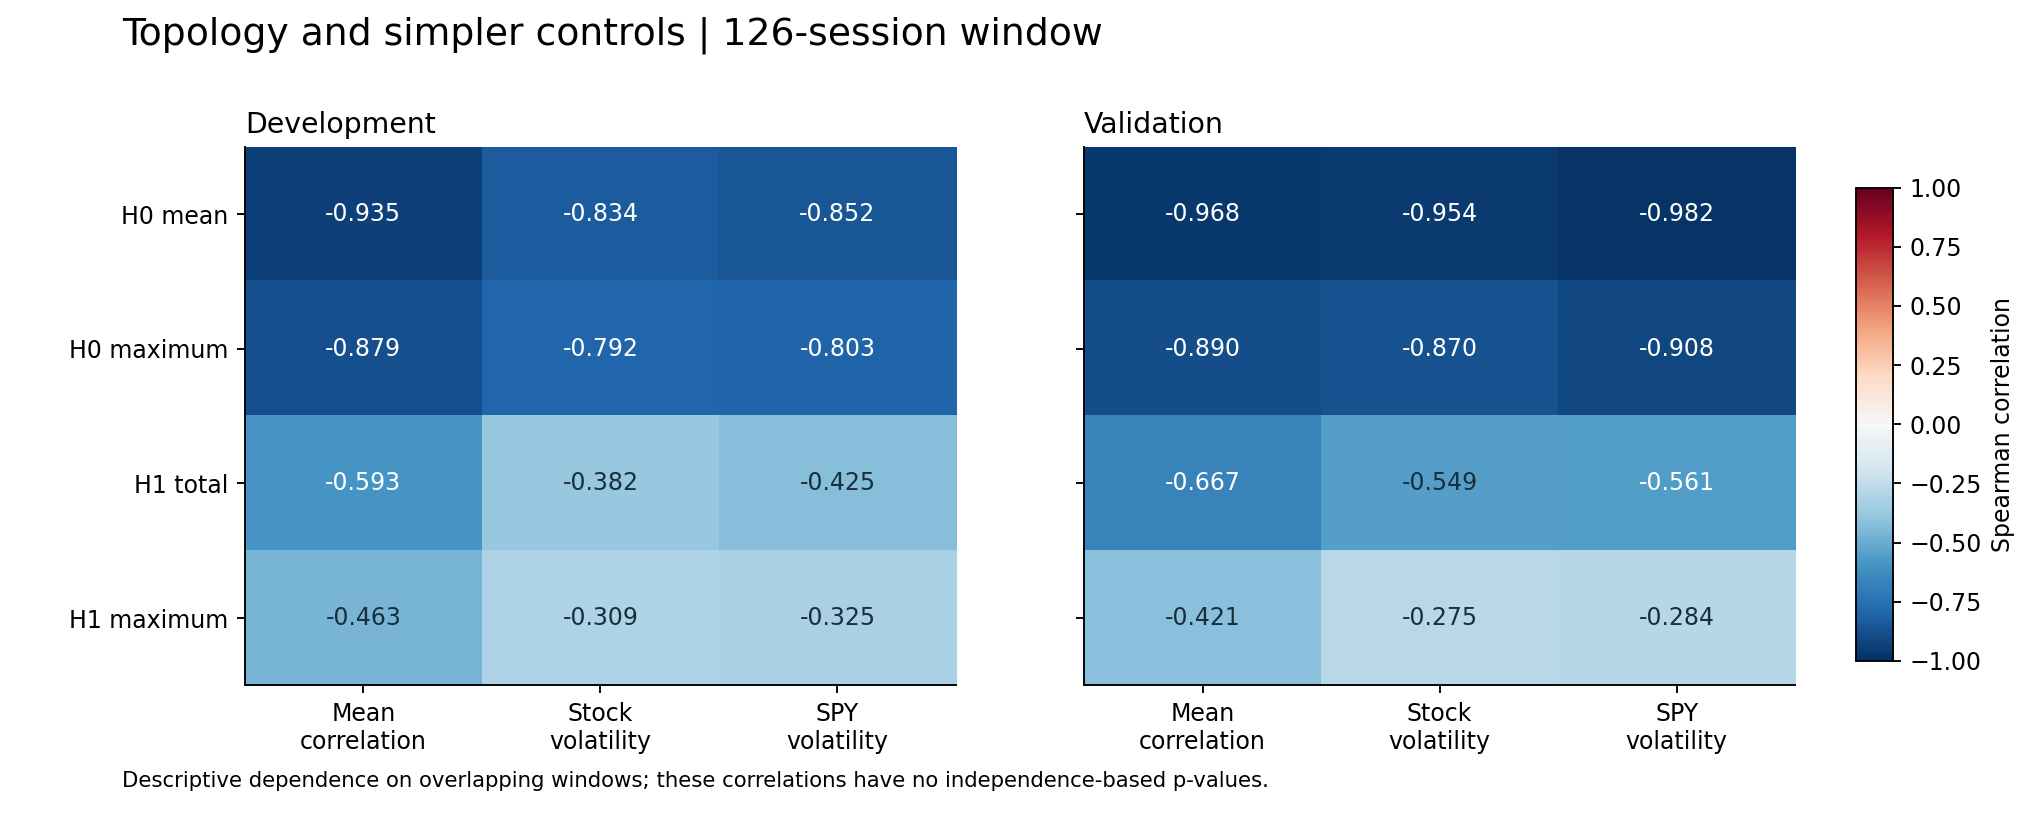

In [6]:
scores = pd.read_csv(output / "control-model-scores.csv")
models = json.loads((output / "control-models.json").read_text())
assert all(m["fitted_last_date"] < "2017-01-01" for m in models.values())
display(scores.loc[scores.window == 126].pivot(index="feature", columns="phase", values="r2"))
display(Image(filename=str(output / "10-control-redundancy.png")))

## 6. Distinguish a stability bound from a stable financial feature
As Chazal et al. (2014) explain in *Persistence stability for geometric complexes*, changes in metric geometry control diagram changes. The same-label maximum distance change bounds the bottleneck distance in this construction. This does **not** imply that H1 rankings remain stable across different estimation windows.

Every alternate-window rank comparison is retained. Overlapping windows make daily features dependent; no independent-observation p-values are reported.

window                     63        252
feature  phase                          
h0_max   development  0.791648  0.699624
         validation   0.651510  0.630346
h0_mean  development  0.784673  0.722836
         validation   0.712599  0.764492
h1_max   development  0.248660  0.081658
         validation   0.293014  0.297400
h1_total development  0.395999  0.285179
         validation   0.534825  0.476906

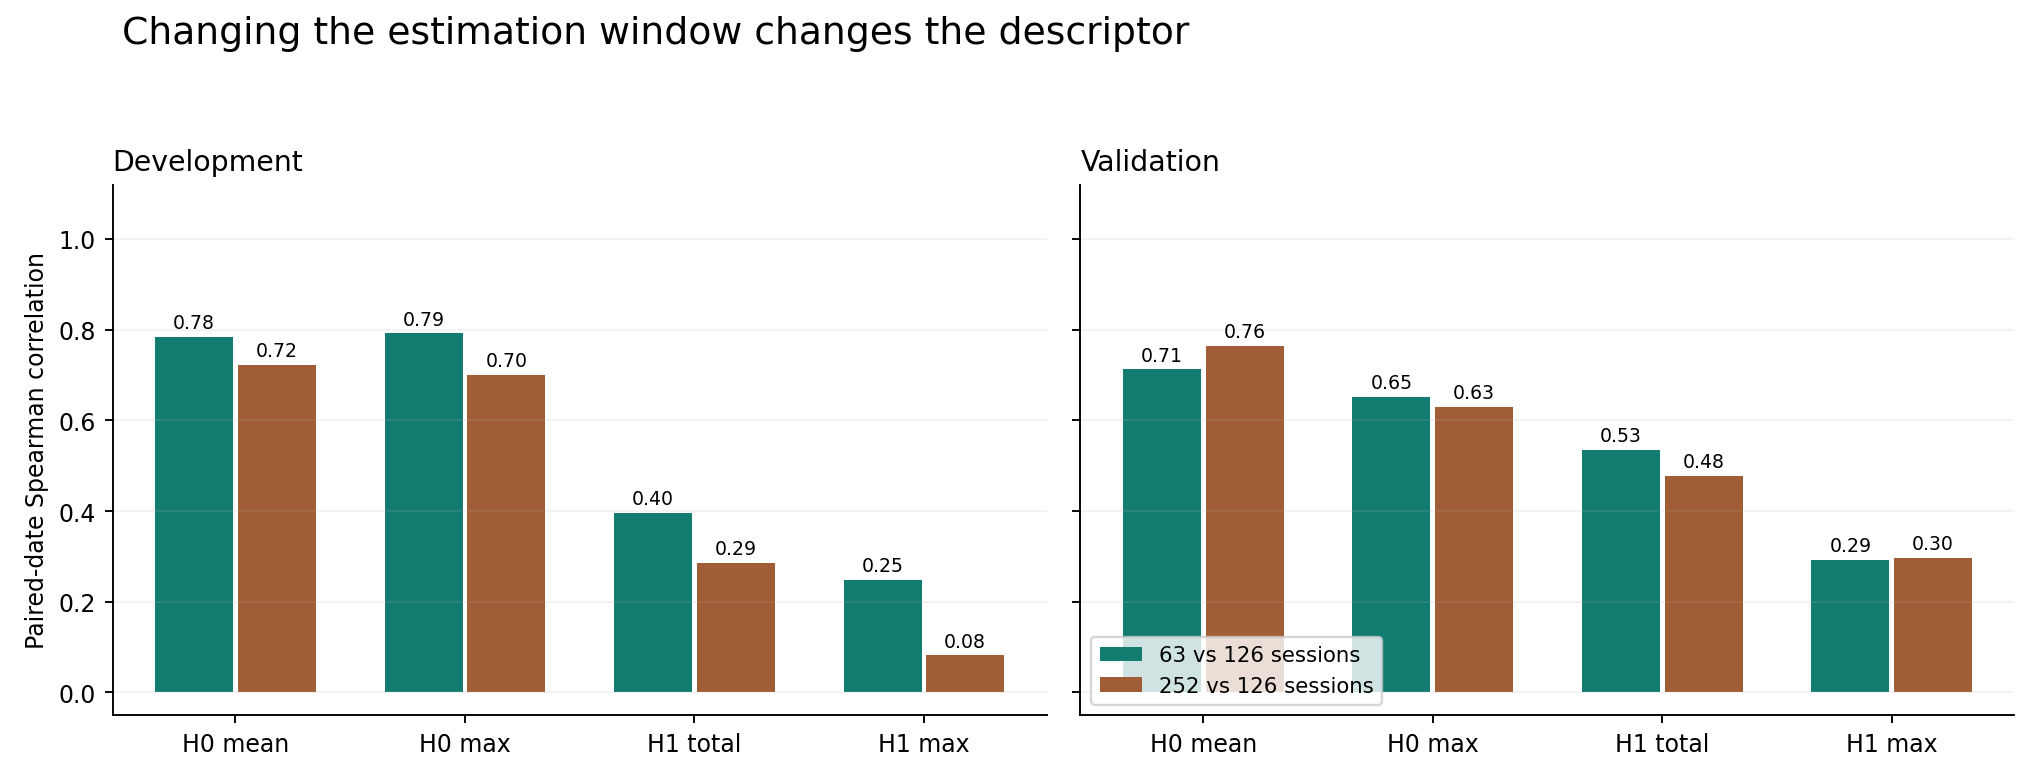

In [7]:
sensitivity = pd.read_csv(output / "window-sensitivity.csv")
checks = pd.read_csv(output / "diagram-stability.csv")
assert len(checks) == 480
assert (checks.bottleneck_distance <= checks.max_distance_change + 2e-6).all()
display(sensitivity.pivot(index=["feature", "phase"], columns="window", values="spearman"))
display(Image(filename=str(output / "11-window-sensitivity.png")))

## 7. Explore persistence landscapes in 3D
As Bubenik (2015) explains in *Statistical topological data analysis using persistence landscapes*, intervals give rise to ordered tent functions:

$$\lambda_k(\varepsilon)=\operatorname{kth\ largest}_{a}\max\{0,\min(\varepsilon-b_a,d_a-\varepsilon)\}\tag{27}$$

Open `outputs/topology/Persistence-Landscape-Explorer.html` in a browser. Rotate, zoom, hover, use the date slider or play 120 monthly frames. The paired diagram displays the actual birth/death intervals. Only integer ranks are defined; joining them as a surface is visual interpolation. All intervals enter the feature summaries even though only five layers are displayed.

def landscape(diagram, grid, layers=5):
    """Bubenik (2015): kth largest interval tent; ranks are discrete."""
    bars = np.asarray(diagram, dtype=float).reshape(-1, 2)
    if not np.isfinite(bars).all() or (bars[:, 1] < bars[:, 0]).any():
        raise ValueError("Landscapes here require finite valid bars")
    x = np.asarray(grid, dtype=float)
    tents = np.maximum(0, np.minimum(x[None, :] - bars[:, :1], bars[:, 1:] - x[None, :]))
    ordered = np.sort(tents, axis=0)[::-1]
    out = np.zeros((layers, len(x)))
    out[:min(layers, len(bars))] = ordered[:layers]
    return out



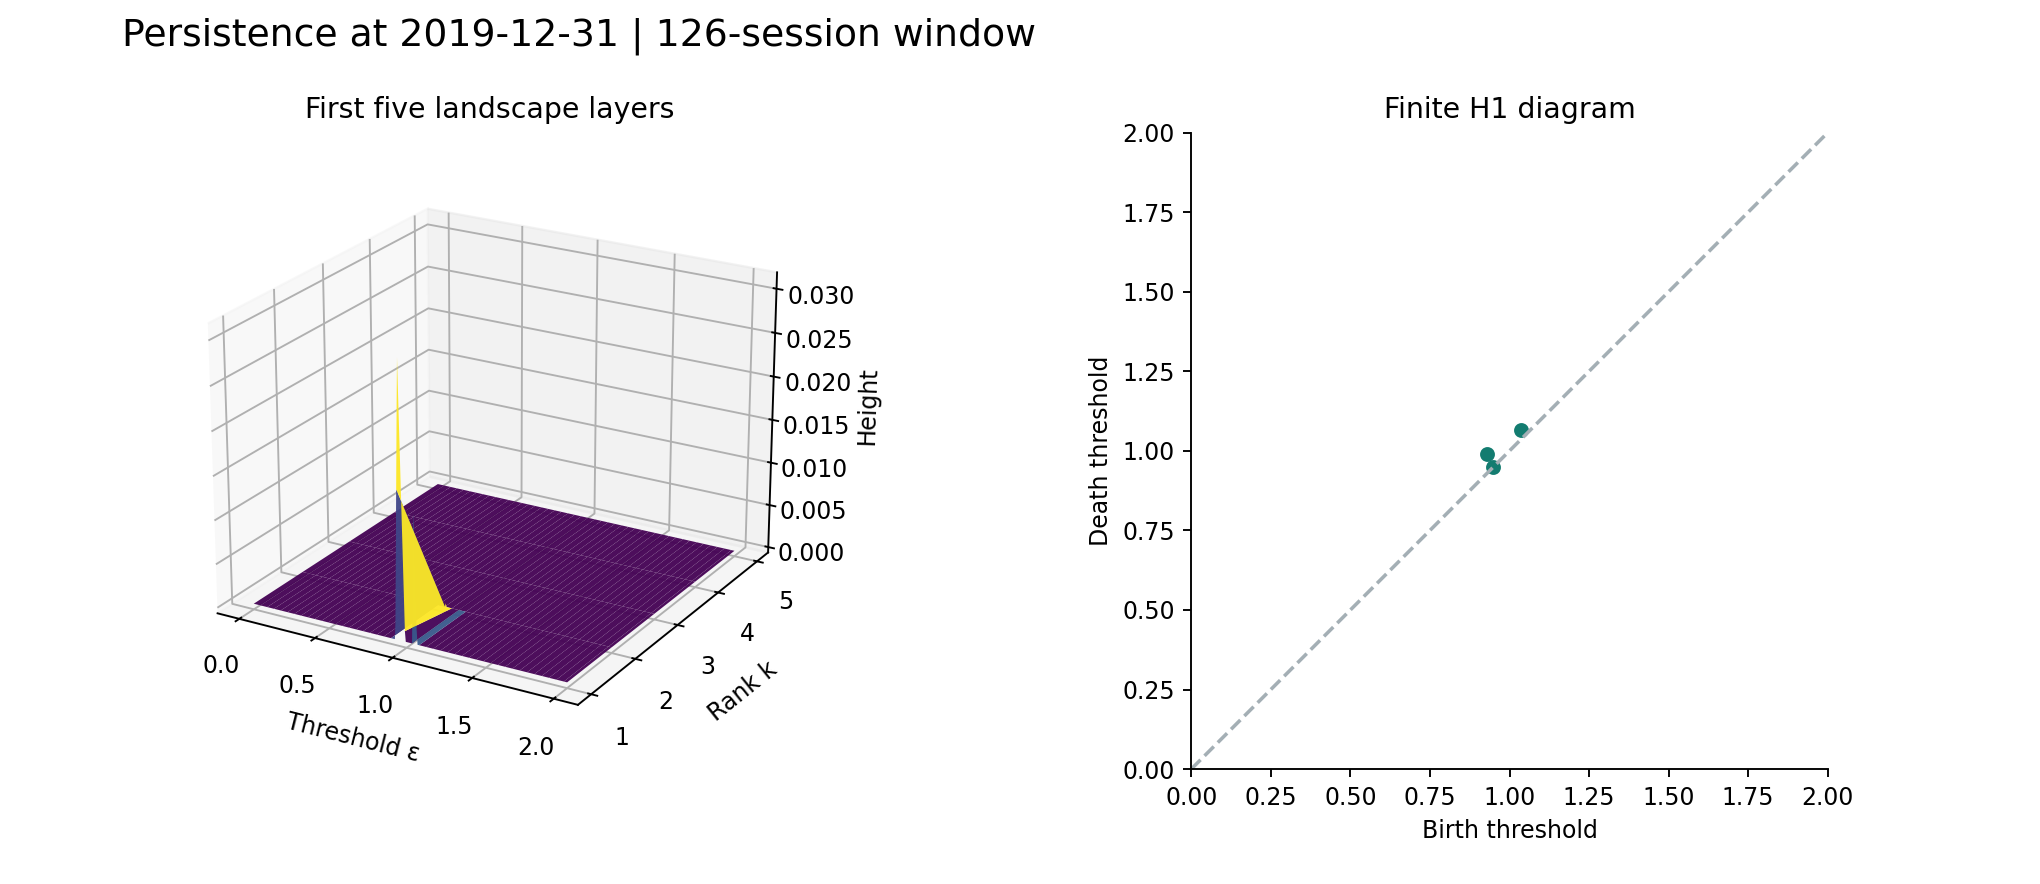

[Open the offline 3D companion](../outputs/topology/Persistence-Landscape-Explorer.html)

In [8]:
print(inspect.getsource(landscape))
display(Image(filename=str(output / "12-persistence-landscape.png")))
display(Markdown("[Open the offline 3D companion](../outputs/topology/Persistence-Landscape-Explorer.html)"))

## 8. Record the setbacks and research decision
The results expose three limitations. H0 mean strongly overlaps mean correlation. The transferred H0-maximum control approximation has negative validation R². H1 maximum is sensitive to the estimation window. Passing all diagram-bound checks does not remove these empirical limitations.

The response is to retain the simpler controls, all declared windows and negative findings, with no topology overlay selected at this stage. The detailed log also records the geometry/infinite-bar forks and the repaired empty-image write. Milestones 1–3 have retrospective evidence-based entries in the same log.

The next milestone must freeze the final evaluation design before releasing the holdout. Current validation has already been observed and cannot become a fresh test.

In [9]:
decision_log = (ROOT / "docs/milestone-decisions.md").read_text()
for milestone in range(1,5):
    assert f"## Milestone {milestone}" in decision_log
print("Problem-solving records cover all four completed milestones.")
print("Final holdout acquired/evaluated:", manifest["final_holdout_acquired_or_evaluated"])
print("Current manuscript: paper/manuscript.md; final PDF deferred.")

Problem-solving records cover all four completed milestones.
Final holdout acquired/evaluated: False
Current manuscript: paper/manuscript.md; final PDF deferred.


## 9. Run the focused engineering checks
The suite contains independent numerical checks, causal timing tests and boundary cases. These checks support correct implementation; they do not establish financial profitability. The notebook executes without opening kernel sockets in the build environment; local VS Code connectivity is a separate setup check.

In [10]:
import subprocess
check = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
                       cwd=ROOT, capture_output=True, text=True)
log = check.stdout + check.stderr
(ROOT / "validation/milestone-4-tests.txt").write_text(log)
print(log)
assert check.returncode == 0

test_circular_continuation_and_constant_series (test_comparison.ComparisonChecks.test_circular_continuation_and_constant_series) ... ok
test_frozen_comparison_protocol_rejects_edits (test_comparison.ComparisonChecks.test_frozen_comparison_protocol_rejects_edits) ... ok
test_hac_matches_bartlett_quadratic_form (test_comparison.ComparisonChecks.test_hac_matches_bartlett_quadratic_form) ... ok
test_matching_gross_preserves_neutrality_and_never_levers_up (test_comparison.ComparisonChecks.test_matching_gross_preserves_neutrality_and_never_levers_up) ... ok
test_paired_mean_interval_is_translation_equivariant (test_comparison.ComparisonChecks.test_paired_mean_interval_is_translation_equivariant) ... ok
test_stationary_bootstrap_matches_exact_mean_variance (test_comparison.ComparisonChecks.test_stationary_bootstrap_matches_exact_mean_variance) ... ok
test_historical_baseline_preserves_milestone_one_rule (test_historical.HistoricalChecks.test_historical_baseline_preserves_milestone_one_rule) .

## References

Bauer, U. (2021) ‘Ripser: efficient computation of Vietoris–Rips persistence barcodes’, *Journal of Applied and Computational Topology*, 5(3), pp. 391–423. doi: [10.1007/s41468-021-00071-5](https://doi.org/10.1007/s41468-021-00071-5).

Bubenik, P. (2015) ‘Statistical topological data analysis using persistence landscapes’, *Journal of Machine Learning Research*, 16(3), pp. 77–102. Available at: [https://jmlr.org/papers/v16/bubenik15a.html](https://jmlr.org/papers/v16/bubenik15a.html) (Accessed: 21 September 2026).

Chazal, F., de Silva, V. and Oudot, S. (2014) ‘Persistence stability for geometric complexes’, *Geometriae Dedicata*, 173(1), pp. 193–214. doi: [10.1007/s10711-013-9937-z](https://doi.org/10.1007/s10711-013-9937-z).

Edelsbrunner, H., Letscher, D. and Zomorodian, A. (2002) ‘Topological Persistence and Simplification’, *Discrete and Computational Geometry*, 28, pp. 511–533. doi: [10.1007/s00454-002-2885-2](https://doi.org/10.1007/s00454-002-2885-2).

Gidea, M. and Katz, Y. (2018) ‘Topological data analysis of financial time series: Landscapes of crashes’, *Physica A: Statistical Mechanics and its Applications*, 491, pp. 820–834. doi: [10.1016/j.physa.2017.09.028](https://doi.org/10.1016/j.physa.2017.09.028).

Golub, G.H. and Van Loan, C.F. (2013) *Matrix Computations*. 4th edn. Johns Hopkins University Press. doi: [10.56021/9781421407944](https://doi.org/10.56021/9781421407944).

Mantegna, R.N. (1999) ‘Hierarchical structure in financial markets’, *The European Physical Journal B*, 11, pp. 193–197. doi: [10.1007/s100510050929](https://doi.org/10.1007/s100510050929).

Tralie, C., Saul, N. and Bar-On, R. (2018) ‘Ripser.py: A lean persistent homology library for Python’, *Journal of Open Source Software*, 3(29), p. 925. doi: [10.21105/joss.00925](https://doi.org/10.21105/joss.00925).